# Electric Vehicle Population Analysis — Exploratory Analysis

In the previous notebook, I cleaned the Washington State EV population dataset.

In this notebook, I explore the cleaned data to understand:

- which EV brands are most common
- which models appear most often
- how BEV and PHEV registrations compare
- which counties and cities have the most EVs
- how EV registrations vary by model year
- how electric range is distributed

This dataset represents registered electric vehicles in Washington State, so I treat the results as population/registration analysis, not global EV sales analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load the cleaned data

I use the cleaned file created in the first notebook.

In [3]:
clean_path = Path("../data/processed/ev_population_cleaned.csv")

ev_df = pd.read_csv(clean_path, low_memory=False)

ev_df.head()

,county,city,state,postal_code,model_year,make,model,electric_vehicle_type,clean_alternative_fuel_vehicle_cafv_eligibility,electric_range,legislative_district,electric_utility
0,Yakima,Yakima,WA,98908.0,2016,BMW,I8,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,14.0,PACIFICORP
1,Yakima,Selah,WA,98942.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,PACIFICORP
2,Snohomish,Marysville,WA,98271.0,2013,TOYOTA,PRIUS,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,6.0,38.0,PUGET SOUND ENERGY INC
3,Yakima,Yakima,WA,98908.0,2021,PORSCHE,CAYENNE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,14.0,PACIFICORP
4,Kitsap,Bainbridge Island,WA,98110.0,2021,POLESTAR,PS2,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,233.0,23.0,PUGET SOUND ENERGY INC


In [4]:
print("Rows:", ev_df.shape[0])
print("Columns:", ev_df.shape[1])

Rows: 285822
Columns: 12


## 2. Quick overview

Before making charts, I check the basic shape of the data: number of brands, models, counties, cities, and EV types.

In [6]:
overview = pd.DataFrame({
    "metric": [
        "Total EV records",
        "Unique makes",
        "Unique models",
        "Unique counties",
        "Unique cities",
        "EV types"
    ],
    "value": [
        len(ev_df),
        ev_df["make"].nunique(),
        ev_df["model"].nunique(),
        ev_df["county"].nunique(),
        ev_df["city"].nunique(),
        ev_df["electric_vehicle_type"].nunique()
    ]
})

overview

,metric,value
0,Total EV records,285822
1,Unique makes,48
2,Unique models,194
3,Unique counties,254
4,Unique cities,918
5,EV types,2


## 3. Most common EV makes

First, I check which manufacturers appear most often in the dataset.

This gives a basic picture of which brands dominate the registered EV population.

In [7]:
top_makes = ev_df["make"].value_counts().head(10)

top_makes

make
TESLA         117392
CHEVROLET      19677
NISSAN         16121
FORD           15639
KIA            14328
TOYOTA         12234
BMW            11688
HYUNDAI        11067
RIVIAN          9098
VOLKSWAGEN      7658
Name: count, dtype: int64

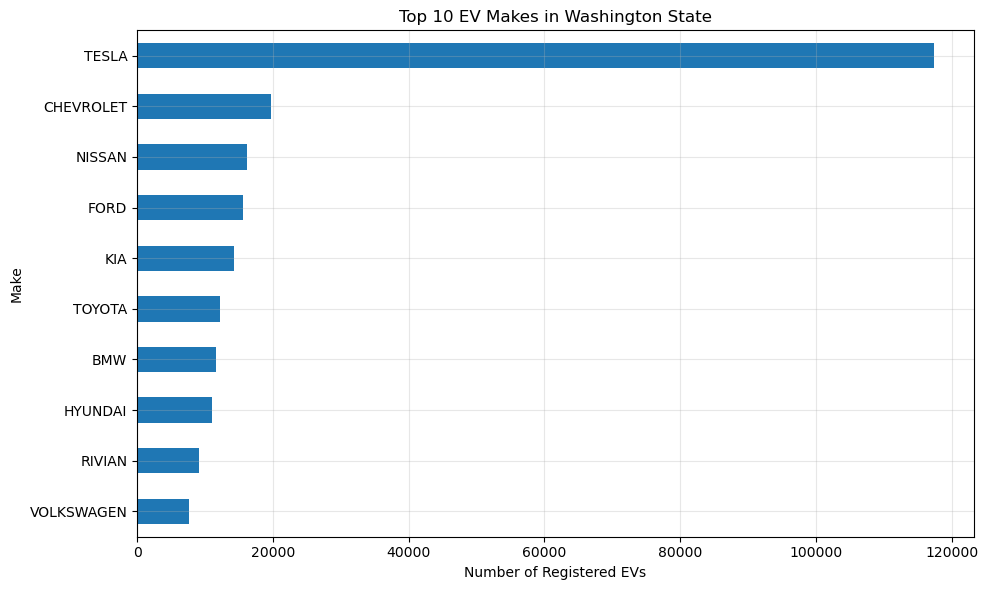

In [8]:
plt.figure(figsize=(10, 6))

top_makes.sort_values().plot(kind="barh")

plt.xlabel("Number of Registered EVs")
plt.ylabel("Make")
plt.title("Top 10 EV Makes in Washington State")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Most common EV models

Brand-level analysis is useful, but model-level analysis shows which specific vehicles are most common.

In [10]:
top_models = (
    ev_df.groupby(["make", "model"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_models

make        model         
TESLA       MODEL Y           62154
            MODEL 3           38316
NISSAN      LEAF              13478
TESLA       MODEL S            7815
CHEVROLET   BOLT EV            7693
TESLA       MODEL X            7109
FORD        MUSTANG MACH-E     6606
HYUNDAI     IONIQ 5            6565
VOLKSWAGEN  ID.4               6148
RIVIAN      R1S                5300
dtype: int64

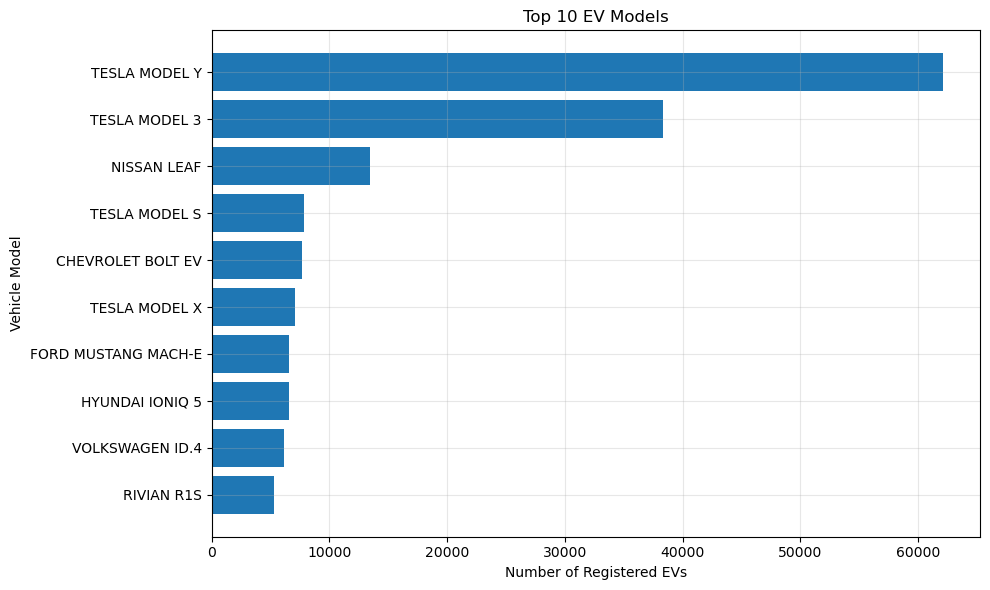

In [11]:
top_models_plot = top_models.reset_index(name="count")
top_models_plot["make_model"] = top_models_plot["make"] + " " + top_models_plot["model"]

plt.figure(figsize=(10, 6))

plt.barh(
    top_models_plot["make_model"][::-1],
    top_models_plot["count"][::-1]
)

plt.xlabel("Number of Registered EVs")
plt.ylabel("Vehicle Model")
plt.title("Top 10 EV Models")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. BEV vs PHEV split

The dataset includes two main EV categories:

- Battery Electric Vehicle, BEV
- Plug-in Hybrid Electric Vehicle, PHEV

I compare them to see whether fully electric vehicles or plug-in hybrids are more common.

In [12]:
ev_type_counts = ev_df["electric_vehicle_type"].value_counts()

ev_type_counts

electric_vehicle_type
Battery Electric Vehicle (BEV)            229876
Plug-in Hybrid Electric Vehicle (PHEV)     55946
Name: count, dtype: int64

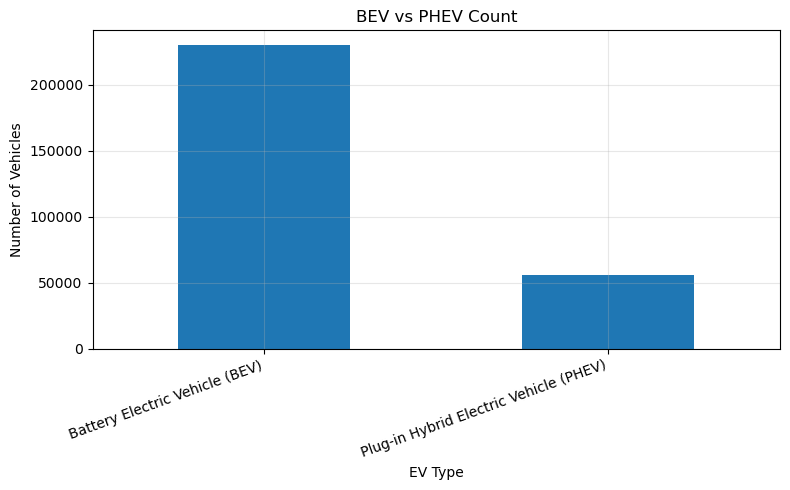

In [13]:
plt.figure(figsize=(8, 5))

ev_type_counts.plot(kind="bar")

plt.xlabel("EV Type")
plt.ylabel("Number of Vehicles")
plt.title("BEV vs PHEV Count")
plt.xticks(rotation=20, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. EV registrations by model year

Model year is not the same as registration year, but it still gives a useful view of how newer EV models appear in the registered vehicle population.

In [14]:
model_year_counts = (
    ev_df["model_year"]
    .value_counts()
    .sort_index()
)

model_year_counts.tail()

model_year
2023    60887
2024    49898
2025    37011
2026    23180
2027       64
Name: count, dtype: int64

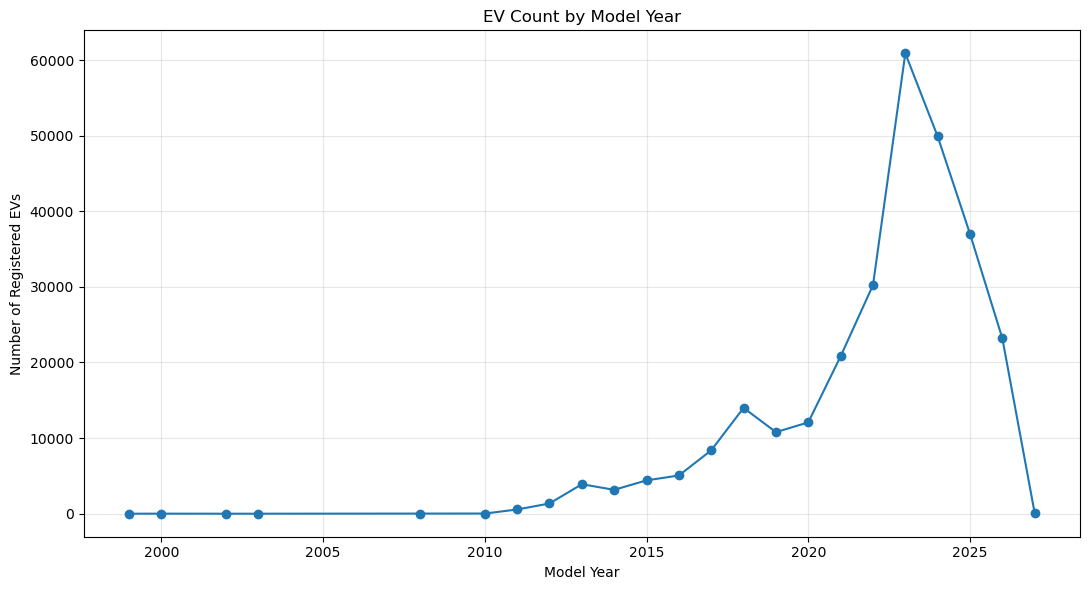

In [15]:
plt.figure(figsize=(11, 6))

plt.plot(model_year_counts.index, model_year_counts.values, marker="o")

plt.xlabel("Model Year")
plt.ylabel("Number of Registered EVs")
plt.title("EV Count by Model Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The line plot may include very old model years with small counts.  
To make the recent trend easier to read, I also look at model years from 2010 onward.

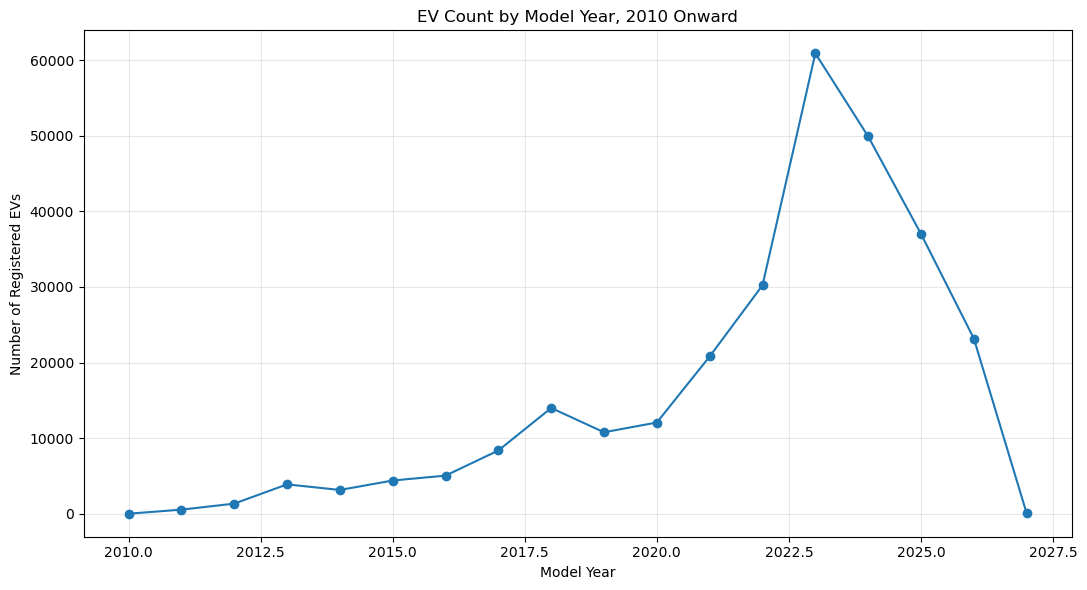

In [17]:
recent_year_counts = model_year_counts[model_year_counts.index >= 2010]

plt.figure(figsize=(11, 6))

plt.plot(recent_year_counts.index, recent_year_counts.values, marker="o")

plt.xlabel("Model Year")
plt.ylabel("Number of Registered EVs")
plt.title("EV Count by Model Year, 2010 Onward")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Counties with the most EVs

Next I check which counties have the largest number of registered EVs.

This is useful because EV distribution is usually not even across regions.

In [18]:
top_counties = ev_df["county"].value_counts().head(10)

top_counties

county
King         140181
Snohomish     35806
Pierce        23596
Clark         17638
Thurston      10404
Kitsap         9728
Spokane        8004
Whatcom        7024
Benton         4156
Skagit         3406
Name: count, dtype: int64

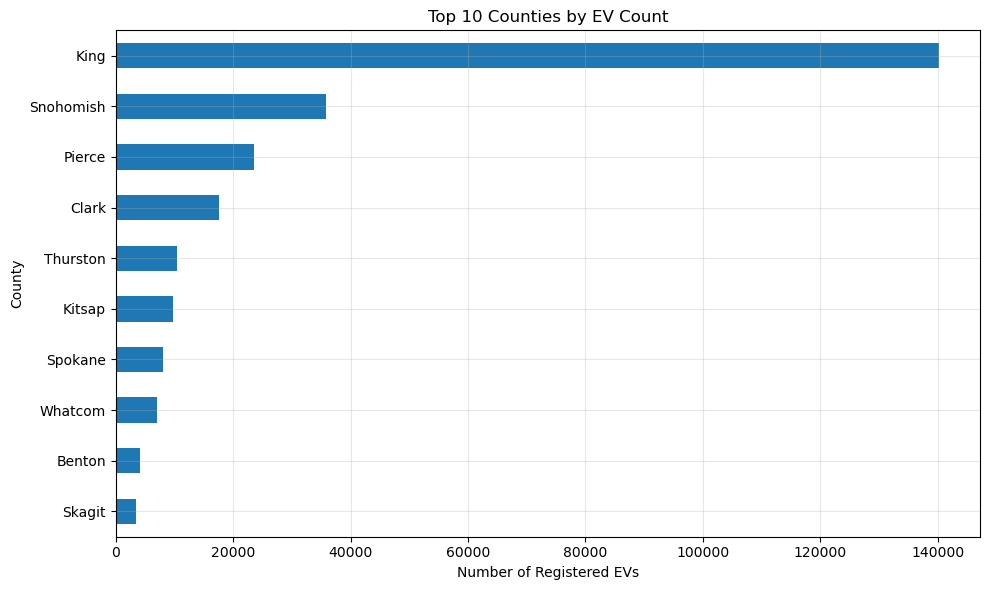

In [19]:
plt.figure(figsize=(10, 6))

top_counties.sort_values().plot(kind="barh")

plt.xlabel("Number of Registered EVs")
plt.ylabel("County")
plt.title("Top 10 Counties by EV Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Cities with the most EVs

County-level results are broad, so I also check the top cities.

In [20]:
top_cities = ev_df["city"].value_counts().head(10)

top_cities

city
Seattle      43876
Bellevue     13912
Vancouver    10635
Redmond       9794
Bothell       9417
Kirkland      8151
Sammamish     7895
Renton        7616
Olympia       6648
Tacoma        6243
Name: count, dtype: int64

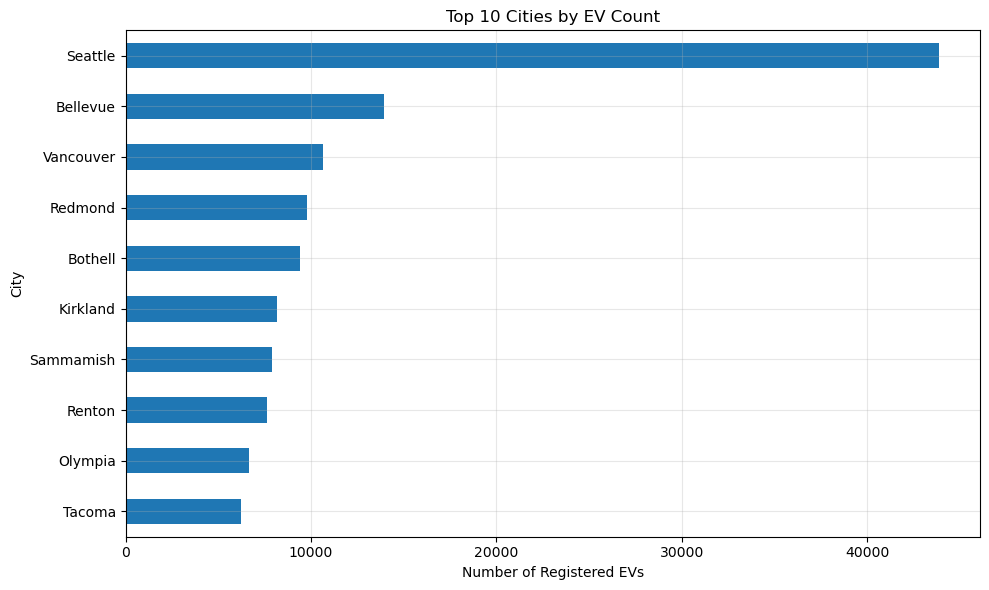

In [21]:
plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(kind="barh")

plt.xlabel("Number of Registered EVs")
plt.ylabel("City")
plt.title("Top 10 Cities by EV Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Electric range distribution

Electric range is useful, but public EV datasets can contain many zero or missing range values.

I first inspect the column before making conclusions.

In [23]:
ev_df["electric_range"].describe()

count    285814.000000
mean         38.150808
std          77.427183
min           0.000000
25%           0.000000
50%           0.000000
75%          32.000000
max         337.000000
Name: electric_range, dtype: float64

In [24]:
zero_range_count = (ev_df["electric_range"] == 0).sum()
missing_range_count = ev_df["electric_range"].isna().sum()

print("Rows with electric range = 0:", zero_range_count)
print("Rows with missing electric range:", missing_range_count)

Rows with electric range = 0: 184287
Rows with missing electric range: 8


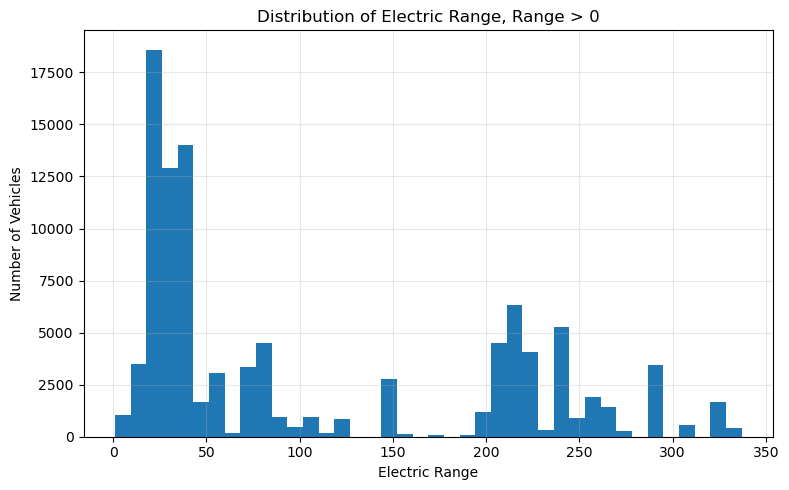

In [25]:
range_df = ev_df[ev_df["electric_range"] > 0].copy()

plt.figure(figsize=(8, 5))

plt.hist(range_df["electric_range"], bins=40)

plt.xlabel("Electric Range")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Electric Range, Range > 0")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Makes with highest average electric range

Now I compare average electric range by make.

To avoid unstable results from very rare brands, I include only makes with at least 100 vehicles with reported range.

In [26]:
make_range = (
    range_df.groupby("make")
    .agg(
        vehicle_count=("make", "count"),
        average_range=("electric_range", "mean")
    )
    .reset_index()
)

make_range_filtered = make_range[make_range["vehicle_count"] >= 100].copy()

top_range_makes = (
    make_range_filtered
    .sort_values("average_range", ascending=False)
    .head(10)
)

top_range_makes["average_range"] = top_range_makes["average_range"].round(1)

top_range_makes

,make,vehicle_count,average_range
31,TESLA,24252,241.5
15,JAGUAR,102,234.0
27,POLESTAR,197,233.0
7,CHEVROLET,9849,151.5
34,VOLKSWAGEN,1053,107.6
26,NISSAN,9584,106.3
28,PORSCHE,1073,92.1
10,FIAT,732,85.6
2,AUDI,2870,76.0
14,HYUNDAI,1653,73.9


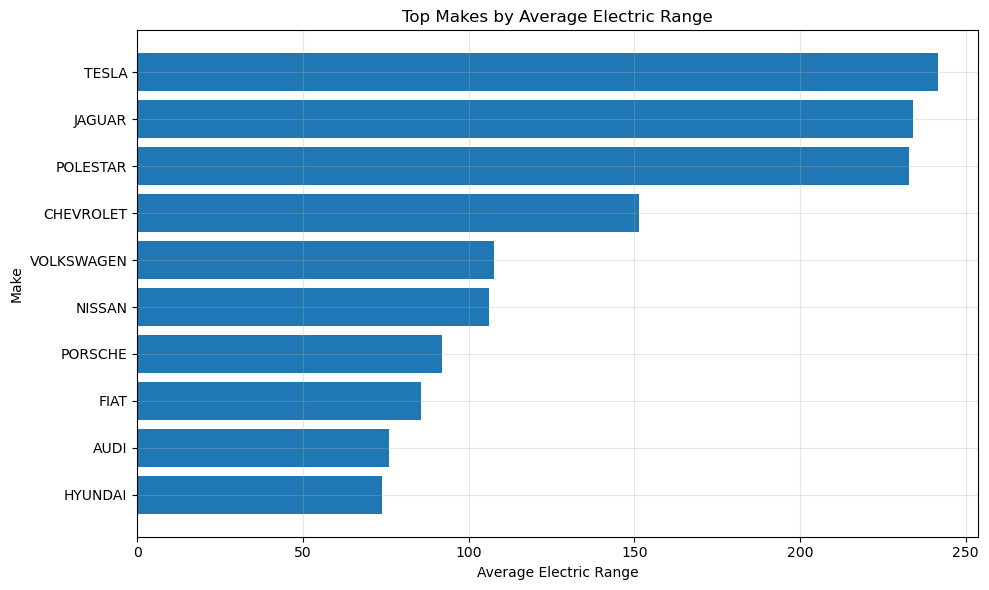

In [27]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_range_makes["make"][::-1],
    top_range_makes["average_range"][::-1]
)

plt.xlabel("Average Electric Range")
plt.ylabel("Make")
plt.title("Top Makes by Average Electric Range")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Save charts 
I save the main charts in the `images/` folder so they can be used in the project README.

In [29]:
images_dir = Path("../images")
images_dir.mkdir(parents=True, exist_ok=True)

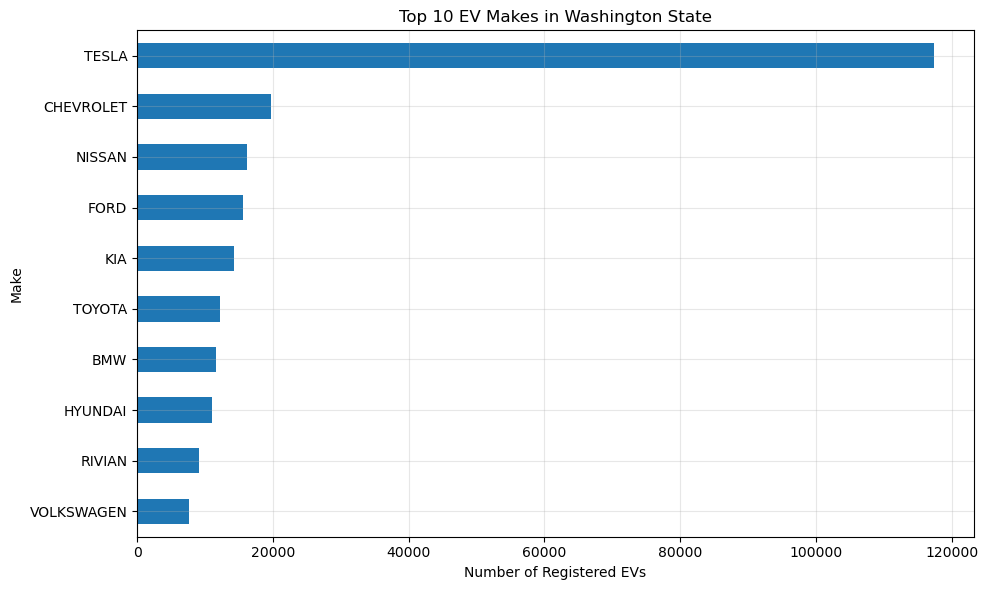

In [30]:
plt.figure(figsize=(10, 6))
top_makes.sort_values().plot(kind="barh")
plt.xlabel("Number of Registered EVs")
plt.ylabel("Make")
plt.title("Top 10 EV Makes in Washington State")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(images_dir / "top_ev_makes.png", dpi=150)
plt.show()

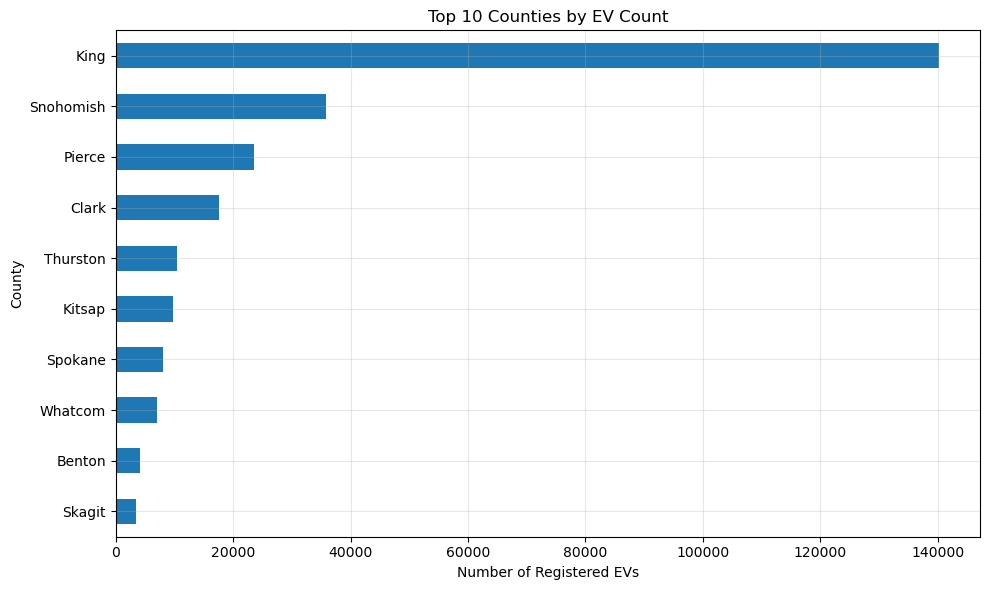

In [31]:
plt.figure(figsize=(10, 6))
top_counties.sort_values().plot(kind="barh")
plt.xlabel("Number of Registered EVs")
plt.ylabel("County")
plt.title("Top 10 Counties by EV Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(images_dir / "top_counties_ev_count.png", dpi=150)
plt.show()

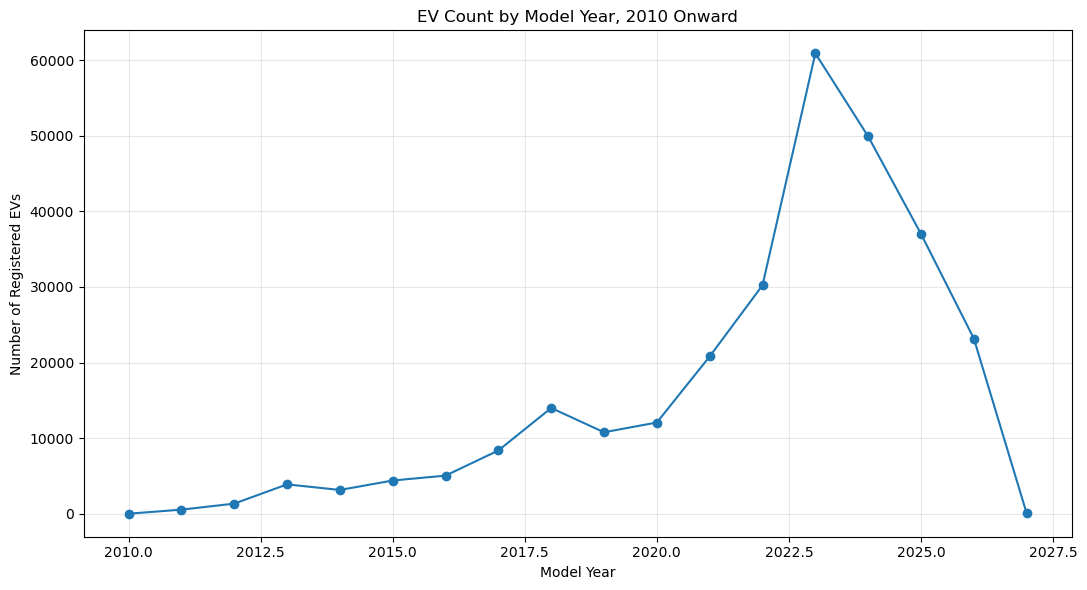

In [32]:
plt.figure(figsize=(11, 6))
plt.plot(recent_year_counts.index, recent_year_counts.values, marker="o")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered EVs")
plt.title("EV Count by Model Year, 2010 Onward")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(images_dir / "ev_count_by_model_year.png", dpi=150)
plt.show()

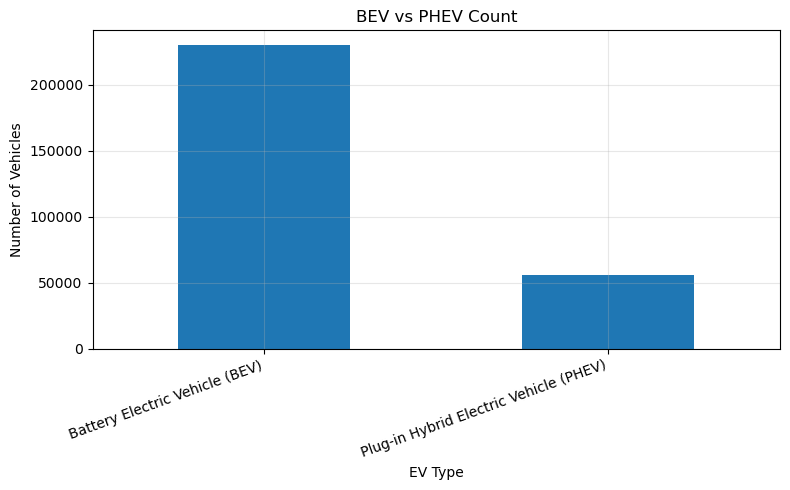

In [33]:
plt.figure(figsize=(8, 5))
ev_type_counts.plot(kind="bar")
plt.xlabel("EV Type")
plt.ylabel("Number of Vehicles")
plt.title("BEV vs PHEV Count")
plt.xticks(rotation=20, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(images_dir / "bev_vs_phev_count.png", dpi=150)
plt.show()

## EDA notes

This analysis gives a practical overview of the EV population in Washington State.

The main views are:

- most common EV makes and models
- BEV vs PHEV split
- EV count by model year
- counties and cities with the most EVs
- electric range distribution

Next step: use SQL to answer similar business questions with database-style queries.